In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("P1_Credit_Risk_Scoring.csv")

In [3]:
df.head()


,Age,Income_Monthly,Employment_Type,Loan_Amount_Requested,Credit_History_Length_Years,Existing_Loans_Count,Past_Defaults,Approved
0,60,52841,Salaried,1786857,13,3,0,0
1,50,85640,Business,549137,6,2,0,0
2,36,180983,Business,706884,16,4,0,1
3,64,153429,Self-Employed,674712,11,3,1,1
4,29,178551,Self-Employed,1900056,19,3,0,1


In [4]:
df.shape

(500, 8)

In [5]:
df.columns


Index(['Age', 'Income_Monthly', 'Employment_Type', 'Loan_Amount_Requested',
       'Credit_History_Length_Years', 'Existing_Loans_Count', 'Past_Defaults',
       'Approved'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Age                          500 non-null    int64 
 1   Income_Monthly               500 non-null    int64 
 2   Employment_Type              500 non-null    object
 3   Loan_Amount_Requested        500 non-null    int64 
 4   Credit_History_Length_Years  500 non-null    int64 
 5   Existing_Loans_Count         500 non-null    int64 
 6   Past_Defaults                500 non-null    int64 
 7   Approved                     500 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 31.4+ KB


In [7]:
df.describe()

,Age,Income_Monthly,Loan_Amount_Requested,Credit_History_Length_Years,Existing_Loans_Count,Past_Defaults,Approved
count,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,43.506000,106562.868000,1.034866e+06,9.274000,2.094000,1.560000,0.498000
std,12.368505,53778.108685,5.541716e+05,5.635107,1.424508,1.130024,0.500497
min,22.000000,15235.000000,5.790600e+04,0.000000,0.000000,0.000000,0.000000
25%,33.000000,59244.750000,5.544898e+05,4.000000,1.000000,1.000000,0.000000
50%,45.000000,107631.500000,1.003996e+06,9.000000,2.000000,2.000000,0.000000
75%,54.000000,152467.500000,1.529771e+06,14.000000,3.000000,3.000000,1.000000
max,64.000000,199943.000000,1.996793e+06,19.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

Age                            0
Income_Monthly                 0
Employment_Type                0
Loan_Amount_Requested          0
Credit_History_Length_Years    0
Existing_Loans_Count           0
Past_Defaults                  0
Approved                       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Approved"].value_counts()

Approved
0    251
1    249
Name: count, dtype: int64

In [11]:
df["Approved"].value_counts(normalize=True) * 100

Approved
0    50.2
1    49.8
Name: proportion, dtype: float64

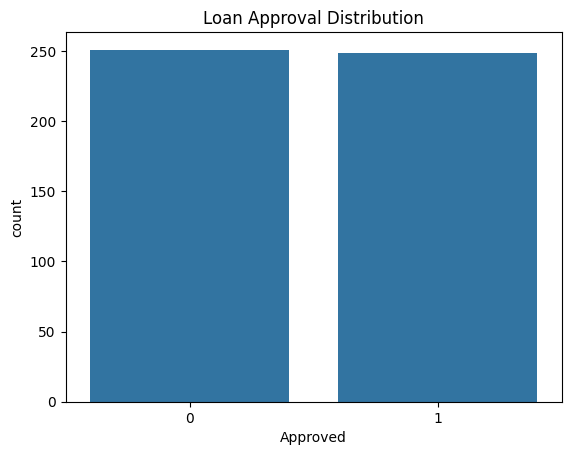

In [12]:
sns.countplot(x="Approved", data=df)
plt.title("Loan Approval Distribution")
plt.show()

In [13]:
df.select_dtypes(include="object").columns

Index(['Employment_Type'], dtype='object')

In [14]:
df["Employment_Type"].unique()

array(['Salaried', 'Business', 'Self-Employed', 'Freelancer'],
      dtype=object)

In [15]:
df = pd.get_dummies(df, columns=["Employment_Type"], drop_first=True)

In [16]:
df.head()

,Age,Income_Monthly,Loan_Amount_Requested,Credit_History_Length_Years,Existing_Loans_Count,Past_Defaults,Approved,Employment_Type_Freelancer,Employment_Type_Salaried,Employment_Type_Self-Employed
0,60,52841,1786857,13,3,0,0,False,True,False
1,50,85640,549137,6,2,0,0,False,False,False
2,36,180983,706884,16,4,0,1,False,False,False
3,64,153429,674712,11,3,1,1,False,False,True
4,29,178551,1900056,19,3,0,1,False,False,True


In [17]:
df.columns

Index(['Age', 'Income_Monthly', 'Loan_Amount_Requested',
       'Credit_History_Length_Years', 'Existing_Loans_Count', 'Past_Defaults',
       'Approved', 'Employment_Type_Freelancer', 'Employment_Type_Salaried',
       'Employment_Type_Self-Employed'],
      dtype='object')

In [18]:
df = df.astype(int)

In [19]:
df.head()

,Age,Income_Monthly,Loan_Amount_Requested,Credit_History_Length_Years,Existing_Loans_Count,Past_Defaults,Approved,Employment_Type_Freelancer,Employment_Type_Salaried,Employment_Type_Self-Employed
0,60,52841,1786857,13,3,0,0,0,1,0
1,50,85640,549137,6,2,0,0,0,0,0
2,36,180983,706884,16,4,0,1,0,0,0
3,64,153429,674712,11,3,1,1,0,0,1
4,29,178551,1900056,19,3,0,1,0,0,1


In [20]:
X = df.drop("Approved", axis=1)
y = df["Approved"]

In [21]:
print(X.shape)
print(y.shape)

(500, 9)
(500,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 9)
(100, 9)
(400,)
(100,)


In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
print(X_train[:5])

[[-1.0959964   1.06280534  0.28246746  0.13476703 -0.71733211 -1.38935532
  -0.54653573  1.68705478 -0.57735027]
 [ 0.59138809 -0.10509739  0.94261319 -1.28383325  1.37706821  1.2867705
  -0.54653573 -0.59274898 -0.57735027]
 [ 0.59138809  0.70773634  1.02480063 -0.75185814  1.37706821 -0.49731338
  -0.54653573  1.68705478 -0.57735027]
 [ 0.02892659 -0.03738613 -1.64739602  1.0213922   1.37706821 -0.49731338
  -0.54653573 -0.59274898 -0.57735027]
 [ 0.75209137  0.46575579 -0.52587477 -1.10650821 -0.71733211  0.39472856
   1.82970656 -0.59274898 -0.57735027]]


In [26]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.92
Precision: 0.8666666666666667
Recall: 0.9512195121951219
F1 Score: 0.9069767441860465
ROC-AUC: 0.9644481190574619


In [28]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93        59
           1       0.87      0.95      0.91        41

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



In [29]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.83
Precision: 0.75
Recall: 0.8780487804878049
F1 Score: 0.8089887640449438
ROC-AUC: 0.930549813972716


In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85        59
           1       0.75      0.88      0.81        41

    accuracy                           0.83       100
   macro avg       0.83      0.84      0.83       100
weighted avg       0.84      0.83      0.83       100



In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,Credit_History_Length_Years,0.289461
1,Income_Monthly,0.280380
5,Past_Defaults,0.195562
2,Loan_Amount_Requested,0.085441
0,Age,0.074223
4,Existing_Loans_Count,0.041981
7,Employment_Type_Salaried,0.013176
8,Employment_Type_Self-Employed,0.010840
6,Employment_Type_Freelancer,0.008936


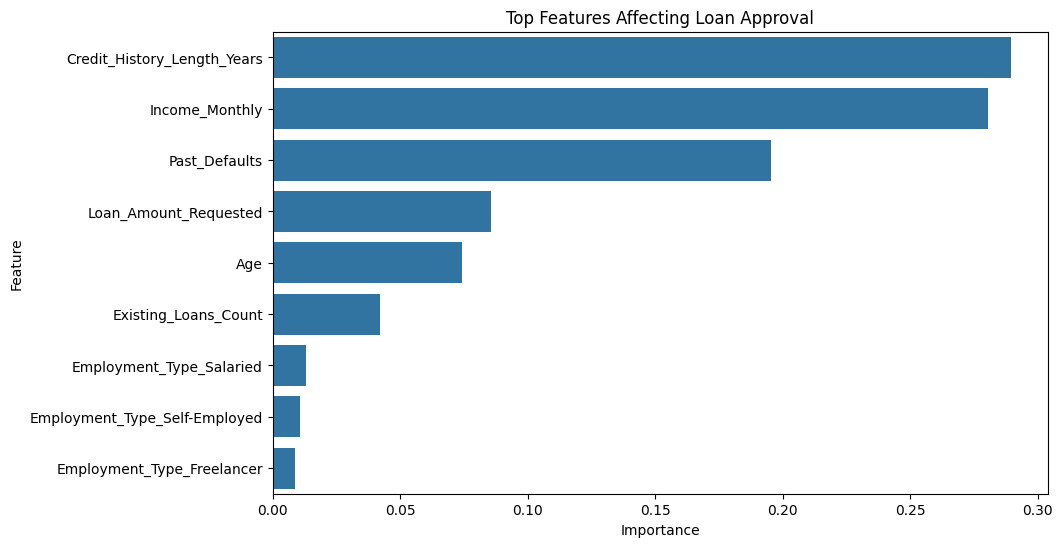

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top Features Affecting Loan Approval")
plt.show()

In [34]:
importance.head(10)

,Feature,Importance
3,Credit_History_Length_Years,0.289461
1,Income_Monthly,0.280380
5,Past_Defaults,0.195562
2,Loan_Amount_Requested,0.085441
0,Age,0.074223
4,Existing_Loans_Count,0.041981
7,Employment_Type_Salaried,0.013176
8,Employment_Type_Self-Employed,0.010840
6,Employment_Type_Freelancer,0.008936


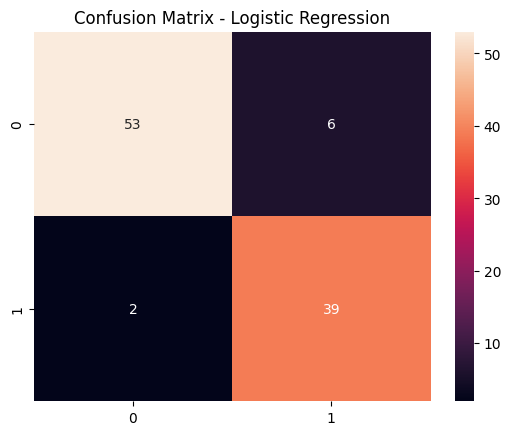

In [35]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [36]:
# Save trained model + scaler before building Streamlit UI

import pickle

# Save Logistic Regression model (recommended final model)
with open("logistic_regression_model.pkl", "wb") as file:
    pickle.dump(lr, file)

# Save Random Forest model (for backup/demo)
with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf, file)

# Save StandardScaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save feature column names (very important for Streamlit prediction form)
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Models + scaler + feature columns saved successfully!")

Models + scaler + feature columns saved successfully!
